# Practical 5: Comprehensive House Price Analysis Project

This notebook is updated according to:
- the **attached CSV file** `melb_data.csv`
- the **Practical 5 flow** from your practical list
- **beginner-friendly code** with clear comments

## Important note
The uploaded file name is **`melb_data.csv`**, but the actual dataset columns match a **house price dataset with `SalePrice` as the target column**.

So this notebook is written according to the **real attached CSV columns** to avoid column mismatch errors.

## Practical 5 requirements covered
- Data loading and initial cleaning
- Missing value handling
- Descriptive statistics
- Histogram and box plot of the target variable
- Outlier detection
- Scatter plots and correlation heatmap
- Top correlated feature selection
- Simple linear regression
- Multiple linear regression
- Model comparison using R-squared


## Step 1: Import Libraries

We import the libraries needed for:
- reading data
- numerical operations
- graphs
- regression modeling


In [1]:
# pandas is used to work with tabular data like CSV files
import pandas as pd

# numpy is used for numerical calculations
import numpy as np

# matplotlib is used to draw basic graphs
import matplotlib.pyplot as plt

# seaborn is used to create better statistical graphs
import seaborn as sns

# train_test_split is used to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# LinearRegression is used to build regression models
from sklearn.linear_model import LinearRegression

# r2_score is used to measure how well the regression model performs
from sklearn.metrics import r2_score


## Step 2: Load the Attached Dataset

This notebook uses the attached file:

- `melb_data.csv`

Even though the file name says `melb_data`, the target column in this CSV is **`SalePrice`**.


In [2]:
# Read the CSV file and store it in a DataFrame named df
df = pd.read_csv("melb_data.csv")

# Display the first 5 rows of the dataset
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 3: Understand the Dataset

This step helps beginners understand:
- number of rows and columns
- column names
- data types
- structure of the dataset


In [3]:
# Print the number of rows and columns in the dataset
print("Shape of dataset:", df.shape)

# Print all column names
print("\nColumn names in the dataset:")
print(df.columns.tolist())


Shape of dataset: (1460, 81)

Column names in the dataset:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Enclo

In [4]:
# Display basic information about the dataset
# This shows column names, non-null counts, and data types
print("Dataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

In [5]:
# Show descriptive statistics for numeric columns
# This gives count, mean, standard deviation, minimum, quartiles, and maximum
df.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Step 4: Check Missing Values

The practical requires data cleaning, so first we count missing values in the dataset.


In [6]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Sort missing values from highest to lowest
missing_values = missing_values.sort_values(ascending=False)

# Display the top 20 columns with missing values
missing_values.head(20)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
MasVnrType         8
Electrical         1
Id                 0
dtype: int64

## Step 5: Select Useful Columns for Analysis

To keep the notebook simple for beginners, we use important numeric columns that are **actually present in the attached CSV**.

### Target column
- `SalePrice`

### Selected predictor columns
- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `BedroomAbvGr`

These columns are easy to understand and are commonly related to house price.


In [7]:
# Select useful columns from the attached dataset
# These columns are present in the uploaded CSV file
selected_columns = [
    "SalePrice",     # target variable
    "OverallQual",   # overall material and finish quality
    "GrLivArea",     # above ground living area
    "GarageCars",    # garage capacity in number of cars
    "GarageArea",    # garage area
    "TotalBsmtSF",   # total basement area
    "1stFlrSF",      # first floor area
    "FullBath",      # number of full bathrooms
    "TotRmsAbvGrd",  # total rooms above ground
    "YearBuilt",     # construction year
    "BedroomAbvGr"   # number of bedrooms above ground
]

# Create a new DataFrame using only the selected columns
df_selected = df[selected_columns].copy()

# Display the first 5 rows of the selected data
df_selected.head()


,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,BedroomAbvGr
0,208500,7,1710,2,548,856,856,2,8,2003,3
1,181500,6,1262,2,460,1262,1262,2,6,1976,3
2,223500,7,1786,2,608,920,920,2,6,2001,3
3,140000,7,1717,3,642,756,961,1,7,1915,3
4,250000,8,2198,3,836,1145,1145,2,9,2000,4


## Step 6: Handle Missing Values

For beginner students, we use a simple method:
- remove rows where the selected columns contain missing values

This method is easy to understand and keeps the practical simple.


In [8]:
# Check missing values in the selected columns
df_selected.isnull().sum()


SalePrice       0
OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
BedroomAbvGr    0
dtype: int64

In [10]:
# Remove rows with missing values in the selected columns
df_clean = df_selected.dropna()

# Print shape before and after cleaning
print("Original shape:", df_selected.shape)
print("Shape after removing missing values:", df_clean.shape)


Original shape: (1460, 11)
Shape after removing missing values: (1460, 11)


## Step 7: Descriptive Statistics of the Target Variable

As required in the practical, we calculate:
- mean
- median
- range
- standard deviation

for the target variable **`SalePrice`**.


In [12]:
df_clean.describe()

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,BedroomAbvGr
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,6.099315,1515.463699,1.767123,472.980137,1057.429452,1162.626712,1.565068,6.517808,1971.267808,2.866438
std,79442.502883,1.382997,525.480383,0.747315,213.804841,438.705324,386.587738,0.550916,1.625393,30.202904,0.815778
min,34900.000000,1.000000,334.000000,0.000000,0.000000,0.000000,334.000000,0.000000,2.000000,1872.000000,0.000000
25%,129975.000000,5.000000,1129.500000,1.000000,334.500000,795.750000,882.000000,1.000000,5.000000,1954.000000,2.000000
50%,163000.000000,6.000000,1464.000000,2.000000,480.000000,991.500000,1087.000000,2.000000,6.000000,1973.000000,3.000000
75%,214000.000000,7.000000,1776.750000,2.000000,576.000000,1298.250000,1391.250000,2.000000,7.000000,2000.000000,3.000000
max,755000.000000,10.000000,5642.000000,4.000000,1418.000000,6110.000000,4692.000000,3.000000,14.000000,2010.000000,8.000000


In [11]:
# Store the target column in a separate variable for easy use
sale_price = df_clean["SalePrice"]

# Calculate the mean of SalePrice
mean_price = sale_price.mean()

# Calculate the median of SalePrice
median_price = sale_price.median()

# Calculate the range of SalePrice
range_price = sale_price.max() - sale_price.min()

# Calculate the standard deviation of SalePrice
std_price = sale_price.std()

# Print all the results
print("Mean of SalePrice:", mean_price)
print("Median of SalePrice:", median_price)
print("Range of SalePrice:", range_price)
print("Standard Deviation of SalePrice:", std_price)


Mean of SalePrice: 180921.19589041095
Median of SalePrice: 163000.0
Range of SalePrice: 720100
Standard Deviation of SalePrice: 79442.50288288663


## Step 8: Histogram of the Target Variable

A histogram helps us understand:
- how house prices are distributed
- whether the data is skewed
- where most values are concentrated


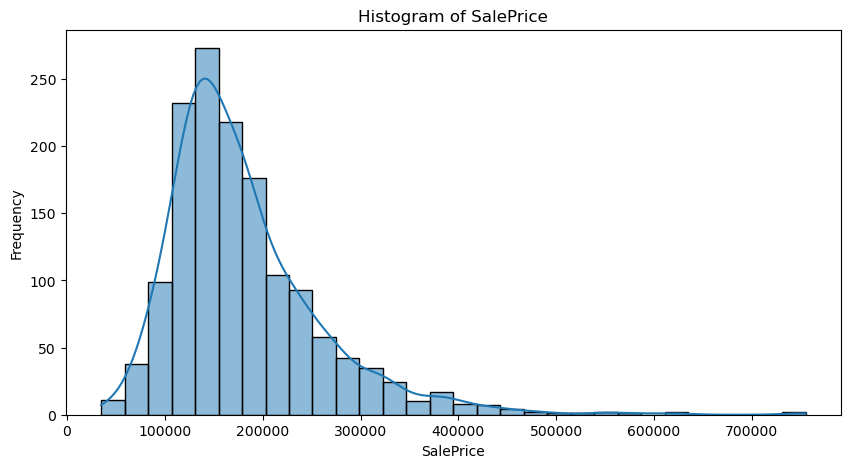

In [13]:
# Create a larger figure for better visibility
plt.figure(figsize=(10, 5))

# Draw the histogram of SalePrice
sns.histplot(df_clean["SalePrice"], bins=30, kde=True)

# Add title and labels
plt.title("Histogram of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

# Show the plot
plt.show()


## Step 9: Box Plot of the Target Variable

A box plot helps us:
- understand the spread of values
- detect possible outliers


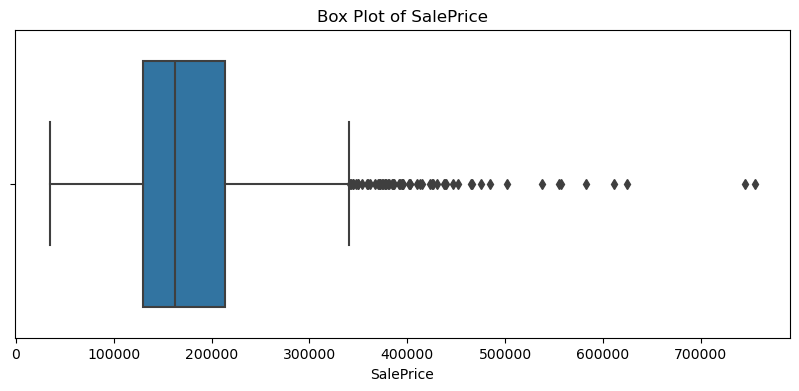

In [14]:
# Create a figure for the box plot
plt.figure(figsize=(10, 4))

# Draw the box plot of SalePrice
sns.boxplot(x=df_clean["SalePrice"])

# Add title and labels
plt.title("Box Plot of SalePrice")
plt.xlabel("SalePrice")

# Show the plot
plt.show()


## Step 10: Outlier Detection Using IQR Method

The practical mentions outliers, so we use the simple **IQR method**.

### Formula
- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1

Values outside the lower and upper limits are treated as outliers.


In [15]:
# Calculate the first quartile
Q1 = df_clean["SalePrice"].quantile(0.25)

# Calculate the third quartile
Q3 = df_clean["SalePrice"].quantile(0.75)

# Calculate the interquartile range
IQR = Q3 - Q1

# Calculate the lower limit for outliers
lower_limit = Q1 - 1.5 * IQR

# Calculate the upper limit for outliers
upper_limit = Q3 + 1.5 * IQR

# Remove rows where SalePrice is outside the acceptable range
df_no_outliers = df_clean[
    (df_clean["SalePrice"] >= lower_limit) & (df_clean["SalePrice"] <= upper_limit)
]

# Print shape before and after outlier removal
print("Shape before outlier removal:", df_clean.shape)
print("Shape after outlier removal :", df_no_outliers.shape)


Shape before outlier removal: (1460, 11)
Shape after outlier removal : (1399, 11)


## Step 11: Correlation Analysis and Feature Selection

Now we find which features are most strongly related to **SalePrice**.
This helps us choose good features for regression models.


In [16]:
# Calculate the correlation matrix for numeric columns
correlation_matrix = df_no_outliers.corr(numeric_only=True)

# Find the correlation of each column with SalePrice
saleprice_correlation = correlation_matrix["SalePrice"].sort_values(ascending=False)

# Display the correlation values
saleprice_correlation


SalePrice       1.000000
OverallQual     0.784294
GrLivArea       0.661325
GarageCars      0.628013
GarageArea      0.607230
FullBath        0.577369
YearBuilt       0.564558
TotalBsmtSF     0.543508
1stFlrSF        0.522785
TotRmsAbvGrd    0.472292
BedroomAbvGr    0.201610
Name: SalePrice, dtype: float64

In [17]:
# Remove SalePrice itself because its correlation with itself is always 1
# Then keep the top 5 most correlated features
top_features = saleprice_correlation.drop("SalePrice").head(5)

# Print the top 5 correlated features
print("Top 5 features most correlated with SalePrice:")
print(top_features)


Top 5 features most correlated with SalePrice:
OverallQual    0.784294
GrLivArea      0.661325
GarageCars     0.628013
GarageArea     0.607230
FullBath       0.577369
Name: SalePrice, dtype: float64


In [18]:
# Convert the selected top features into a Python list
top_feature_names = top_features.index.tolist()

# Print the selected feature names
print("Selected feature names:", top_feature_names)


Selected feature names: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'FullBath']


## Step 12: Scatter Plots for Bivariate Analysis

Each scatter plot shows the relationship between:
- one selected feature
- the target variable `SalePrice`


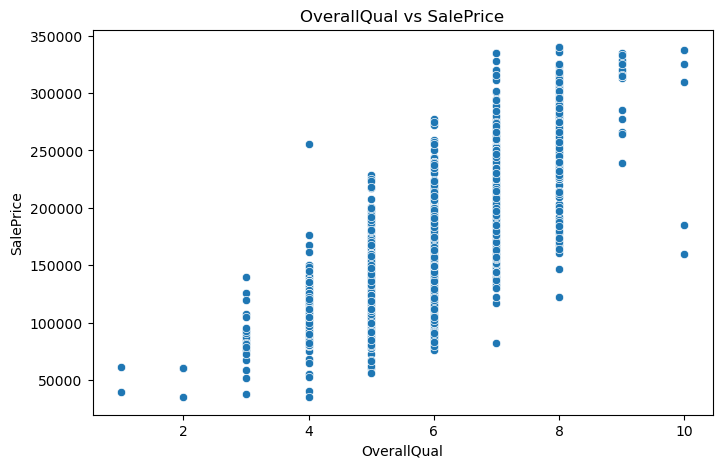

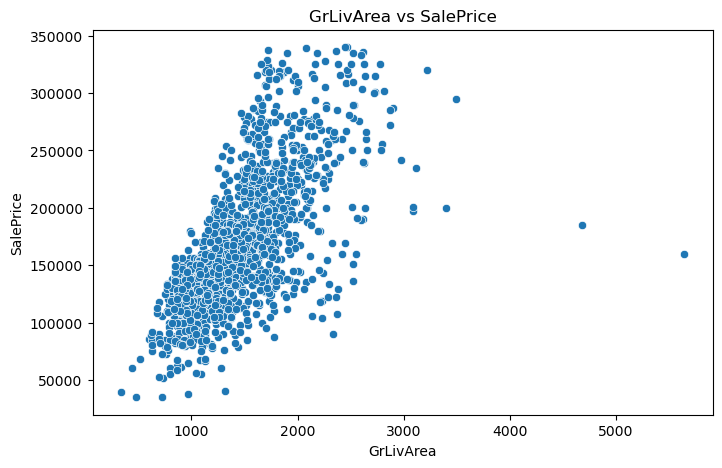

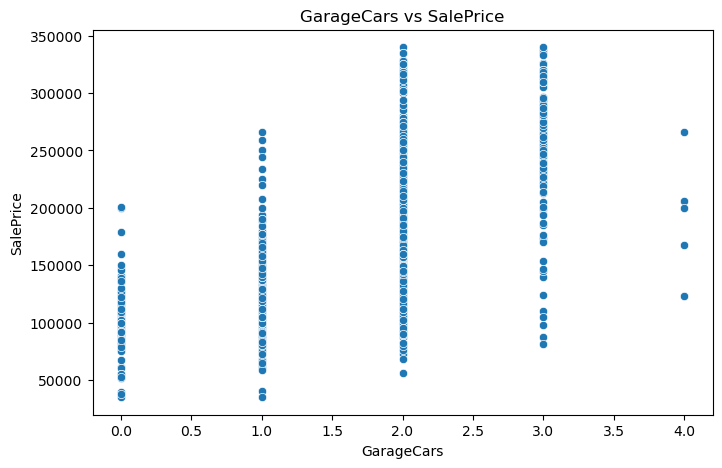

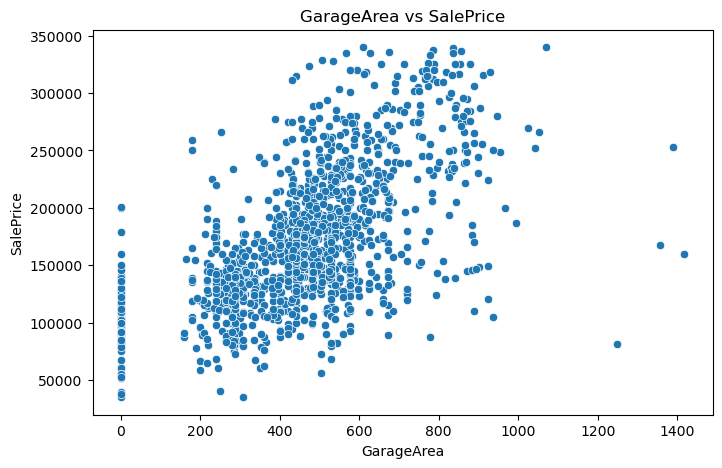

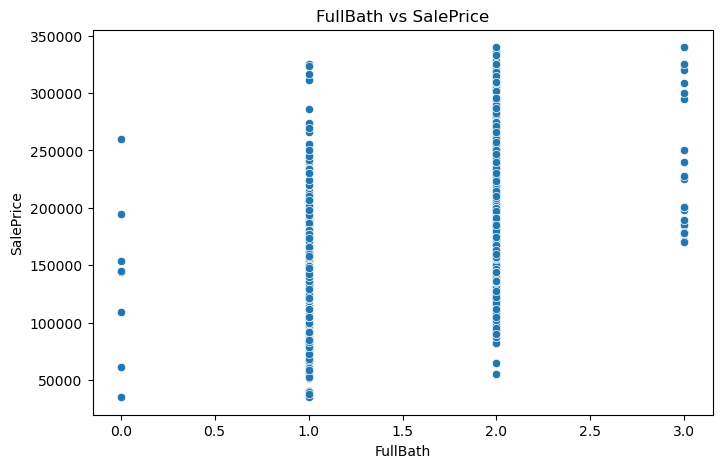

In [19]:
# Create one scatter plot for each selected top feature
for feature in top_feature_names:

    # Create a new figure
    plt.figure(figsize=(8, 5))

    # Draw the scatter plot
    sns.scatterplot(x=df_no_outliers[feature], y=df_no_outliers["SalePrice"])

    # Add title and labels
    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")

    # Show the graph
    plt.show()


## Step 13: Correlation Heatmap

A heatmap helps us visually understand how strongly the important features are related to each other and to `SalePrice`.


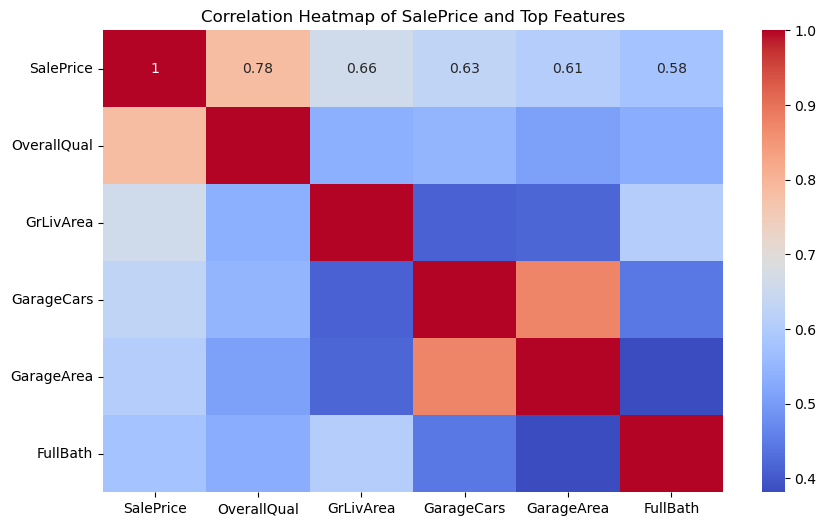

In [20]:
# Create a list of columns for the heatmap
heatmap_columns = ["SalePrice"] + top_feature_names

# Create a figure for the heatmap
plt.figure(figsize=(10, 6))

# Draw the heatmap
sns.heatmap(df_no_outliers[heatmap_columns].corr(), annot=True, cmap="coolwarm")

# Add title
plt.title("Correlation Heatmap of SalePrice and Top Features")

# Show the heatmap
plt.show()


## Step 14: Simple Linear Regression

Simple linear regression uses only **one best predictor**.

As required in the practical, we use the **single best correlated feature**.


In [21]:
# Select the best single feature from the top feature list
best_feature = top_feature_names[0]

# Create input X using only one feature
X_simple = df_no_outliers[[best_feature]]

# Create target y using SalePrice
y = df_no_outliers["SalePrice"]

# Split data into training and testing sets
# 80% data is used for training and 20% data is used for testing
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Create the simple linear regression model
simple_model = LinearRegression()

# Train the model using the training data
simple_model.fit(X_train_simple, y_train_simple)

# Predict the target values for the test data
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate the R-squared value
r2_simple = r2_score(y_test_simple, y_pred_simple)

# Print the model result
print("Best feature used:", best_feature)
print("R-squared of Simple Linear Regression:", r2_simple)


Best feature used: OverallQual
R-squared of Simple Linear Regression: 0.6248999001508398


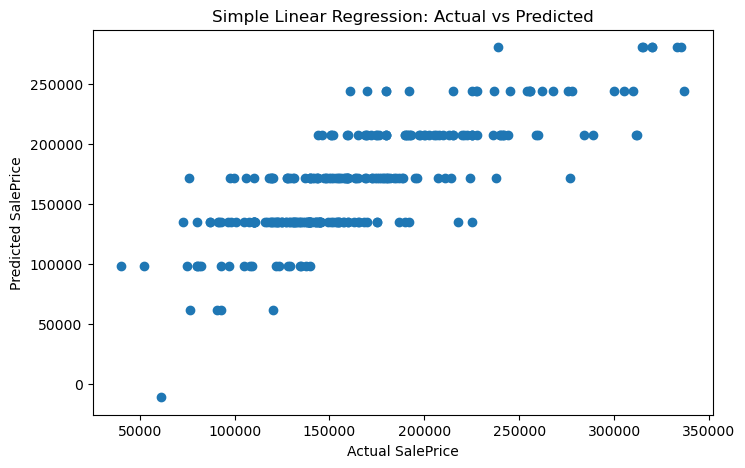

In [22]:
# Plot actual values versus predicted values for the simple regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test_simple, y_pred_simple)
plt.title("Simple Linear Regression: Actual vs Predicted")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()


## Step 15: Multiple Linear Regression

Multiple linear regression uses **3 to 5 selected features**.

As required in the practical, we use the top correlated features found above.


In [23]:
# Create input X using all selected top features
X_multiple = df_no_outliers[top_feature_names]

# Create target y using SalePrice
y = df_no_outliers["SalePrice"]

# Split the data into training and testing sets
X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)

# Create the multiple linear regression model
multiple_model = LinearRegression()

# Train the multiple regression model
multiple_model.fit(X_train_multiple, y_train_multiple)

# Make predictions using the test data
y_pred_multiple = multiple_model.predict(X_test_multiple)

# Calculate the R-squared value
r2_multiple = r2_score(y_test_multiple, y_pred_multiple)

# Print the model result
print("Features used in Multiple Linear Regression:")
print(top_feature_names)
print("R-squared of Multiple Linear Regression:", r2_multiple)


Features used in Multiple Linear Regression:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'FullBath']
R-squared of Multiple Linear Regression: 0.7741040938319186


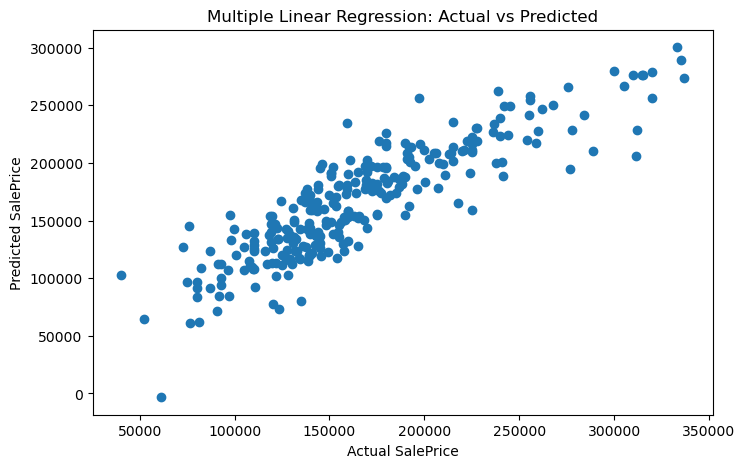

In [24]:
# Plot actual values versus predicted values for the multiple regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test_multiple, y_pred_multiple)
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()


## Step 16: Compare Both Models

The practical asks us to compare:
- Simple Linear Regression
- Multiple Linear Regression

We compare them using **R-squared**.


In [25]:
# Print both R-squared values together
print("R-squared of Simple Linear Regression  :", r2_simple)
print("R-squared of Multiple Linear Regression:", r2_multiple)


R-squared of Simple Linear Regression  : 0.6248999001508398
R-squared of Multiple Linear Regression: 0.7741040938319186


In [26]:
# Create a small table to compare the two models
comparison_df = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "R_squared": [r2_simple, r2_multiple]
})

# Display the comparison table
comparison_df


,Model,R_squared
0,Simple Linear Regression,0.624900
1,Multiple Linear Regression,0.774104


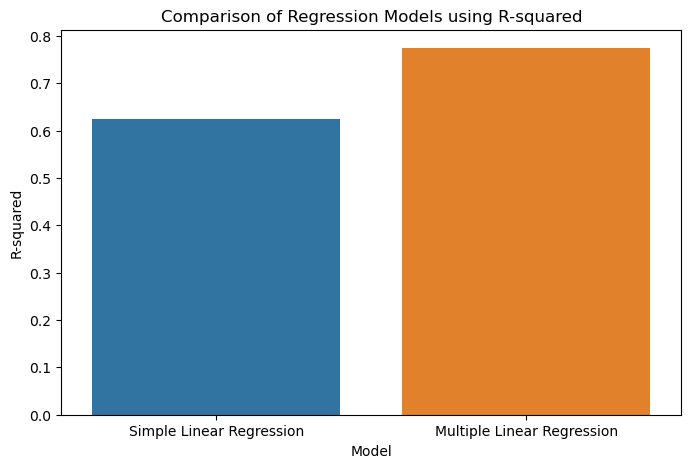

In [27]:
# Draw a bar chart to compare the R-squared values visually
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="R_squared")
plt.title("Comparison of Regression Models using R-squared")
plt.xlabel("Model")
plt.ylabel("R-squared")
plt.show()


## Step 17: Final Conclusion

Students can write a short conclusion based on:
- how missing values were handled
- whether outliers were found
- which features most strongly affect house price
- which regression model performed better
- why multiple regression may perform better than simple regression


# 🔷 TASK SET 1:

## 🎯 Theme: From Model → Interpretation → Decision

---

## 🧠 Task 1: Feature Impact Analysis

### 📌 Instructions:
Based on the regression model built:

1. Identify **top 3 important features**
2. Explain:
   - How each feature affects price (positively/negatively)
   - Why it affects price (real-world reasoning)

---

## ⚙️ Task 2: Model Sensitivity Analysis

### 📌 Instructions:
Take one sample input and:

1. Change **one feature at a time** (e.g., Rooms, Distance)
2. Observe change in predicted price

### Answer:
- Which feature causes **maximum change**?
- Which feature causes **minimum change**?
- Does the model behave logically?

---

## 📊 Task 3: Error Analysis

### 📌 Instructions:
1. Identify **3 cases** where prediction ≠ actual price
2. Analyze:
   - Why error occurred
   - Which feature may be missing

---

## 🧠 Task 4: What-if Scenario (Decision Making)

### 📌 Instructions:
You are a real estate advisor.

Given two houses:
- House A: Near city, small size
- House B: Far from city, large size

### Tasks:
1. Predict prices using your model
2. Recommend which is better investment
3. Justify your answer using:
   - Model output
   - Logical reasoning

---

## Practical-5 Submission Section (Minimum Required)

This section covers:
- Data loading and cleaning
- Descriptive and univariate analysis
- Bivariate analysis and top feature selection
- Simple and multiple linear regression with R-squared comparison

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set(style="whitegrid")

df = pd.read_csv("melb_data.csv")
print("Dataset shape:", df.shape)

# Keep numeric columns and target
if "SalePrice" not in df.columns:
    raise ValueError("Expected target column 'SalePrice' not found in melb_data.csv")

numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.dropna(subset=["SalePrice"])

# Missing value handling for features
numeric_df = numeric_df.fillna(numeric_df.median(numeric_only=True))

# Descriptive and univariate analysis
summary_cols = ["SalePrice"]
summary_cols += [c for c in ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "1stFlrSF"] if c in numeric_df.columns]
summary = pd.DataFrame({
    "mean": numeric_df[summary_cols].mean(),
    "median": numeric_df[summary_cols].median(),
    "min": numeric_df[summary_cols].min(),
    "max": numeric_df[summary_cols].max(),
    "range": numeric_df[summary_cols].max() - numeric_df[summary_cols].min(),
    "std": numeric_df[summary_cols].std()
})
print("\nPrimary statistical measures:")
display(summary)

plt.figure(figsize=(8, 4))
sns.histplot(numeric_df["SalePrice"], kde=True, bins=30)
plt.title("SalePrice Distribution (Histogram)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=numeric_df["SalePrice"])
plt.title("SalePrice Distribution (Box Plot)")
plt.tight_layout()
plt.show()

# Bivariate analysis and feature selection
corr = numeric_df.corr(numeric_only=True)["SalePrice"].drop("SalePrice", errors="ignore").sort_values(key=np.abs, ascending=False)
top_features = corr.head(5).index.tolist()
print("Top correlated features:", top_features)

plt.figure(figsize=(10, 6))
heat_cols = ["SalePrice"] + top_features
sns.heatmap(numeric_df[heat_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (SalePrice + Top Features)")
plt.tight_layout()
plt.show()

for feat in top_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=numeric_df, x=feat, y="SalePrice", alpha=0.5)
    plt.title(f"{feat} vs SalePrice")
    plt.tight_layout()
    plt.show()

# Modeling: Simple linear regression (best single predictor)
best_feature = top_features[0]
X_simple = numeric_df[[best_feature]]
y = numeric_df["SalePrice"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)
simple_model = LinearRegression()
simple_model.fit(Xs_train, ys_train)
ys_pred = simple_model.predict(Xs_test)
r2_simple = r2_score(ys_test, ys_pred)

# Modeling: Multiple linear regression (top 3-5 predictors)
X_multi = numeric_df[top_features]
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)
multi_model = LinearRegression()
multi_model.fit(Xm_train, ym_train)
ym_pred = multi_model.predict(Xm_test)
r2_multi = r2_score(ym_test, ym_pred)

comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "Features Used": [best_feature, ", ".join(top_features)],
    "R_squared": [r2_simple, r2_multi]
})
print("\nModel comparison:")
display(comparison)

print("\nConclusion (minimum):")
print("Multiple linear regression is expected to perform better if it captures more relevant price drivers.")